# Mini-Project 3
## Lecture 8 - Computer Arithmetic & Numerical Accuracy
### Milestone 1

In [1]:
# Packages
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import statistics

# Adds mandelbrot-nsc to sys.path so lecture_files can be imported
sys.path.append(str(Path("..").resolve()))

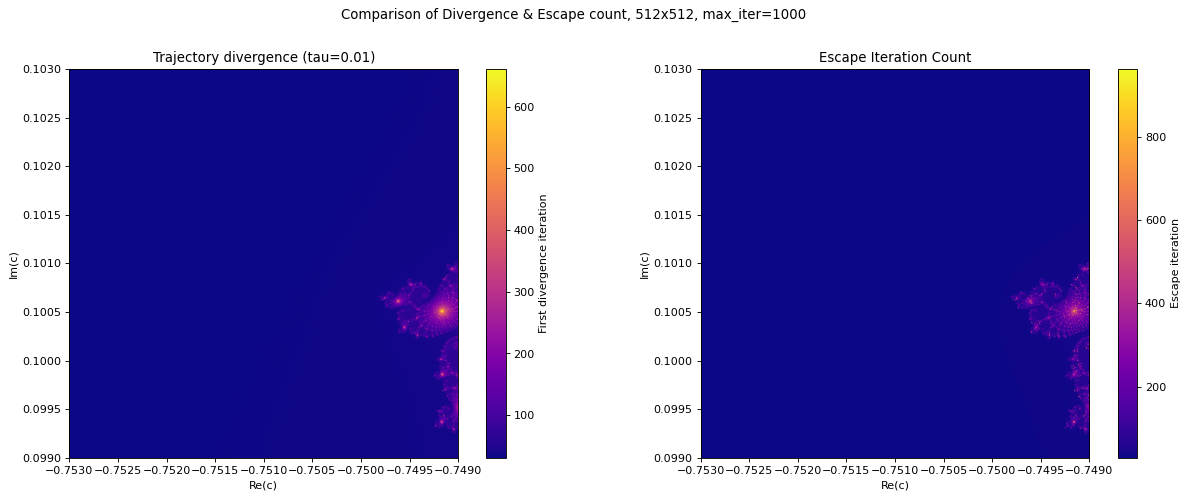

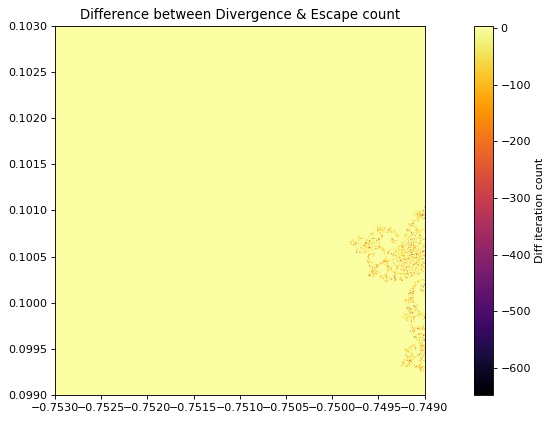

Pixels diverging before max_iter: 262144
Total pixels: 262144
The fraction of pixels diverging before max_iter: 1.00


In [2]:
import lecture_py_files.mandelbrot_8 as mb8 

N = 512
x_dim = (-0.7530, -0.7490)
y_dim = (0.0990, 0.1030)
#x_dim = (-0.750, -0.7490)
#y_dim = (0.0990, 0.1010)
max_iter = 1000
tau = 0.01

# Plot trajectory and escape count
diverge = mb8.mandelbrot_trajectory_divergence(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter, tau=tau)
escape = mb8.mandelbrot_escape_count(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter)

fig, axes = plt.subplots(1, 2, figsize=(16,6), dpi=80)
im0 = axes[0].imshow(diverge, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='plasma', origin='lower', aspect='equal')
axes[0].set_title(f'Trajectory divergence (tau={tau})')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')
fig.colorbar(im0, ax=axes[0], label='First divergence iteration')
im1 = axes[1].imshow(escape, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='plasma', origin='lower', aspect='equal')
axes[1].set_title('Escape Iteration Count')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')
fig.colorbar(im1, ax=axes[1], label='Escape iteration')
plt.suptitle(f'Comparison of Divergence & Escape count, {N}x{N}, {max_iter=}', y=1.02)
plt.tight_layout()
plt.show()

# Inspecting difference between diverge and escape
diff = diverge - escape
count = np.sum(diff < 0)

plt.figure(figsize=(16,6), dpi=80)
plt.imshow(diff, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
plt.colorbar(label='Diff iteration count')
plt.title(f'Difference between Divergence & Escape count')

plt.show()

#Fraction diverging before max_iter
count = np.sum(diverge < max_iter)
pixels = N**2
fraction = count / (pixels)
print(f'Pixels diverging before max_iter: {count}')
print(f'Total pixels: {pixels}')
print(f'The fraction of pixels diverging before max_iter: {fraction:.2f}')    

Observations to make:

- What fraction of pixels diverge before max iter?
  
    The fraction of pixels diverging before max_iter is 0.86 (for the full frame):
    ```python
    x_dim = (-2.5, 1.0)
    y_dim = (-1.5, 1.5)
    ```

- Where do trajectories diverge early? Compare visually to the escape-count map.
  
    Early divergence appears in the dark regions outside the Mandelbrot set and along its boundary filaments. These are exactly the areas where orbits escape quickly rather than staying bounded. When inspecting the difference between the trajectories and the escape count, the trajectories is seen to diverge earliest in the boundaries where the escape count is high.

- Does early divergence correlate with high escape iteration counts?
  
    It correlates inversely. Early divergence corresponds to low escape iteration counts. Conversely, the bright yellow regions (high iteration counts) indicate points that remain bounded much longer (inside or near the Mandelbrot set), which does not have early divergence.

### Milestone 2

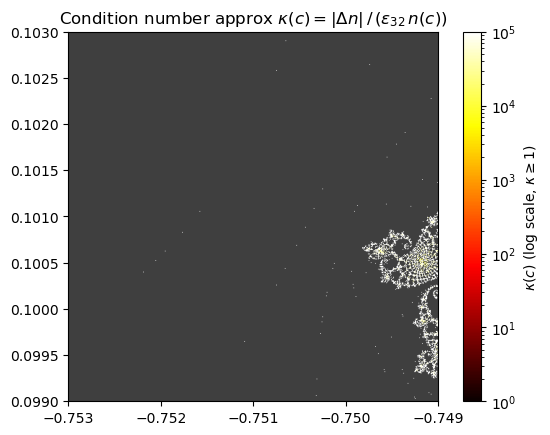

In [3]:
import lecture_py_files.mandelbrot_8 as mb8 

N = 512
x_dim = (-0.7530, -0.7490)
y_dim = (0.0990, 0.1030)
max_iter = 1000

kappa, cmap_k, vmax = mb8.mandelbrot_sensitivity_map(N=N, max_iter=max_iter, x_dim=x_dim, y_dim=y_dim)

plt.figure()
plt.imshow(kappa, cmap=cmap_k, origin='lower',
           extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]],
           norm=LogNorm(vmin=1, vmax=vmax))
plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title(r'Condition number approx $\kappa(c) = |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()

Observations:
- Where is κ largest? Does it match the boundary in M1?
  
    κ is largest at the boundaries between the interior pixels and the exterior as seen on the plot. Therefore it matches the boundaries from M1.
    Furthermore, κ is also large at various pixels in the exterior of the plot.
  
- What is κ for interior pixels (n = max iter)?

    For interior pixels the κ is calculated to $\kappa(c) = \frac{|\Delta n|}{\varepsilon_{32} \cdot n(c)}, \Delta n = n(c+ \delta) - n(c)$.
    Therefore, if $n = \text{max\_iter}$, then $\kappa(c) = \frac{0}{\varepsilon_{32} \cdot max_iter)}$. This means that $\kappa$ mostly collapse to 0, while meaningful structure only appears near the boundary where $\Delta n \neq 0$.

- Comparison of M1 and M2 maps:
  
    Visually comparing the M1 and M2 maps, shows the same seahorse valley map. The exterior region, with low divergence count, low escape count and low $\kappa$.
    At the boundaries $\kappa$ is higly sensitive having values of $\kappa >> 1$, while at the boundaries the divergence count and escape count, transition between low and high, which results in the maps being visually equal.

# Lecture 9 - Testing & Documentation

## Milestone 1 - Pass Count
Record pass count and coverage % in your performance notebook

The pass count is 19 out of 20 tests. The failure is the comparison between numpy and naive implementation. This failure is because the numpy implementation does not have a speedup of 10x compared to the naive implementation.

In [4]:
from pathlib import Path
import subprocess

result = subprocess.run(
    [
        "pytest",
        "lecture_py_files/test_mandelbrot.py",
        "-v",
        "--tb=no",      # removes long tracebacks
        "-rF"           # show only failed tests summary
    ],
    cwd=Path("..").resolve(),
    capture_output=True,
    text=True
)

print(result.stdout)

============================= test session starts =============================
platform win32 -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\mathi\miniforge3\envs\nsc2026\python.exe
cachedir: .pytest_cache
rootdir: C:\UNI\8.Semester\numerical_scientific_computing\mandelbrot-nsc
plugins: anyio-4.12.1, cov-7.1.0
collecting ... collected 20 items

lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[0j-100-100-mandelbrot_point_naive] PASSED [  5%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[0j-100-100-mandelbrot_point_numba] PASSED [ 10%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(5+0j)-100-1-mandelbrot_point_naive] PASSED [ 15%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(5+0j)-100-1-mandelbrot_point_numba] PASSED [ 20%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(-2.5+0j)-100-1-mandelbrot_point_naive] PASSED [ 25%]
lecture_py_files/test_mandelbrot.py::test_numba

## Milestone 1 - Coverage Percentage

The coverage % is seen below the code.

In [5]:
result = subprocess.run(
    [
        "pytest",
        "lecture_py_files/test_mandelbrot.py",
        "--cov=.",
        "--tb=no"      # removes long tracebacks
    ],
    cwd=Path("..").resolve(),
    capture_output=True,
    text=True
)

print(result.stdout)

============================= test session starts =============================
platform win32 -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0
rootdir: C:\UNI\8.Semester\numerical_scientific_computing\mandelbrot-nsc
plugins: anyio-4.12.1, cov-7.1.0
collected 20 items

lecture_py_files\test_mandelbrot.py ....................                 [100%]

=============================== tests coverage ================================
______________ coverage: platform win32, python 3.11.14-final-0 _______________

Name                                  Stmts   Miss  Cover
---------------------------------------------------------
lecture_py_files\__init__.py              0      0   100%
lecture_py_files\mandelbrot_1_2.py       69     27    61%
lecture_py_files\mandelbrot_3.py         89     64    28%
lecture_py_files\mandelbrot_4.py         58     58     0%
lecture_py_files\mandelbrot_5.py         98     68    31%
lecture_py_files\mandelbrot_6.py         14     14     0%
lecture_py_files\mandelbrot

## Milestone 1 - Ruff Check
Checks all mandelbrot files in /lecture_py_files

In [11]:
!ruff check ../lecture_py_files

All checks passed!


# Lecture 10 - GPU Computing

## Milestone 1
Mandelbrot analyzed using GPU, with float32 kernel. Including timing of mandelbrot GPU performance with float32 and resulting image.

GPU 1024x1024: 0.3 ms
GPU 1024x1024: 0.0003 s


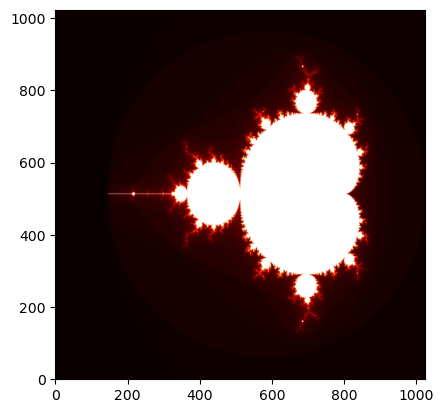

In [6]:
import lecture_py_files.mandelbrot_gpu as gpu

N = 1024
max_iter = 100
x_dim = (-2.5, 1.0)
y_dim = (-1.5, 1.5)

elapsed, image = gpu.mandelbrot_gpu_f32(N=N, max_iter=max_iter, x_dim=x_dim, y_dim=y_dim)

print(f'GPU {N}x{N}: {elapsed*1e3:.1f} ms')
print(f'GPU {N}x{N}: {elapsed:.4f} s')
plt.imshow(image, cmap='hot', origin='lower')
plt.axis('on')
plt.show()


## Milestone 2
Comparison of mandelbrot GPU using float32 and float64. Includes comparison at different N (1024, 2048, 4096, 8192)
In overall, float32 performs better while the images are identical at all resolutions.

GPU 1024x1024 for float32: 0.0002 s
GPU 1024x1024 for float64: 0.0047 s

GPU 2048x2048 for float32: 0.0006 s
GPU 2048x2048 for float64: 0.0177 s

GPU 4096x4096 for float32: 0.0021 s
GPU 4096x4096 for float64: 0.0687 s

GPU 8192x8192 for float32: 0.0073 s
GPU 8192x8192 for float64: 0.2316 s



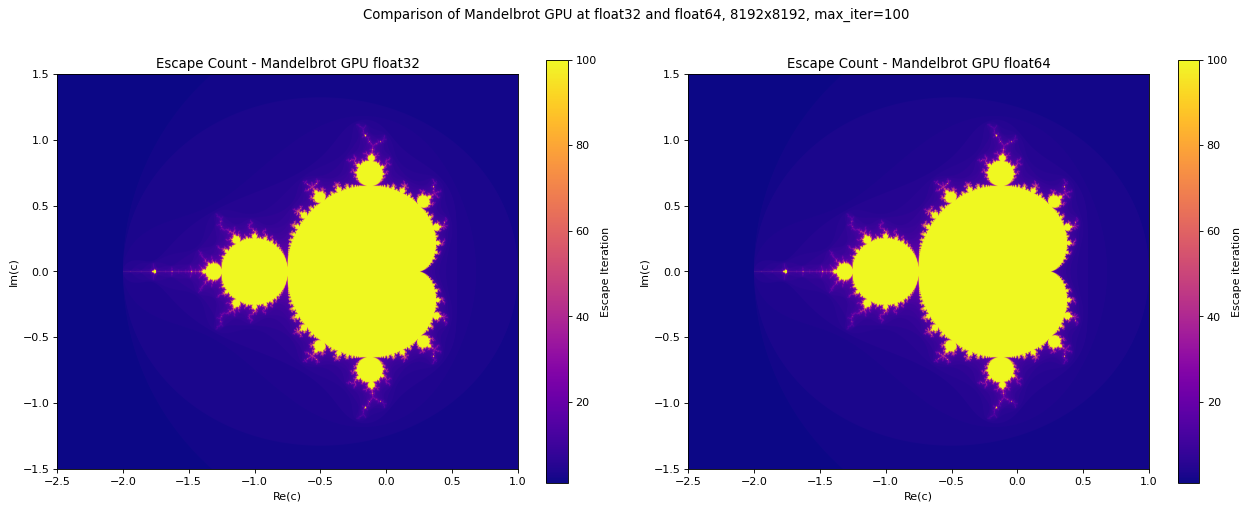

In [7]:
N = [1024, 2048, 4096, 8192]
max_iter = 100
x_dim = (-2.5, 1.0)
y_dim = (-1.5, 1.5)

for n in N:
    # Return timings
    elapsed_f32, image_f32 = gpu.mandelbrot_gpu_f32(N=n, max_iter=max_iter, x_dim=x_dim, y_dim=y_dim)
    elapsed_f64, image_f64 = gpu.mandelbrot_gpu_f64(N=n, max_iter=max_iter, x_dim=x_dim, y_dim=y_dim)

    print(f'GPU {n}x{n} for float32: {elapsed_f32:.4f} s')
    print(f'GPU {n}x{n} for float64: {elapsed_f64:.4f} s\n')

# Plot image of float32 and float64 at N=8192
fig, axes = plt.subplots(1, 2, figsize=(16,6), dpi=80)
im0 = axes[0].imshow(image_f32, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='plasma', origin='lower', aspect='equal')
axes[0].set_title('Escape Count - Mandelbrot GPU float32')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')
fig.colorbar(im0, ax=axes[0], label='Escape Iteration')
im1 = axes[1].imshow(image_f64, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='plasma', origin='lower', aspect='equal')
axes[1].set_title('Escape Count - Mandelbrot GPU float64')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')
fig.colorbar(im1, ax=axes[1], label='Escape iteration')
plt.suptitle(f'Comparison of Mandelbrot GPU at float32 and float64, {n}x{n}, {max_iter=}', y=1.02)
plt.tight_layout()
plt.show()

## Milestone 3
Final benchmark of all implementations including Mandelbrot GPU at float32 and float 64.
Timings from MP2 is used for all implementations except the GPUs.
The evaluation is tested for N=[1024, 2048, 4096, 8192] and max_iter=100 as these were used in MP2.

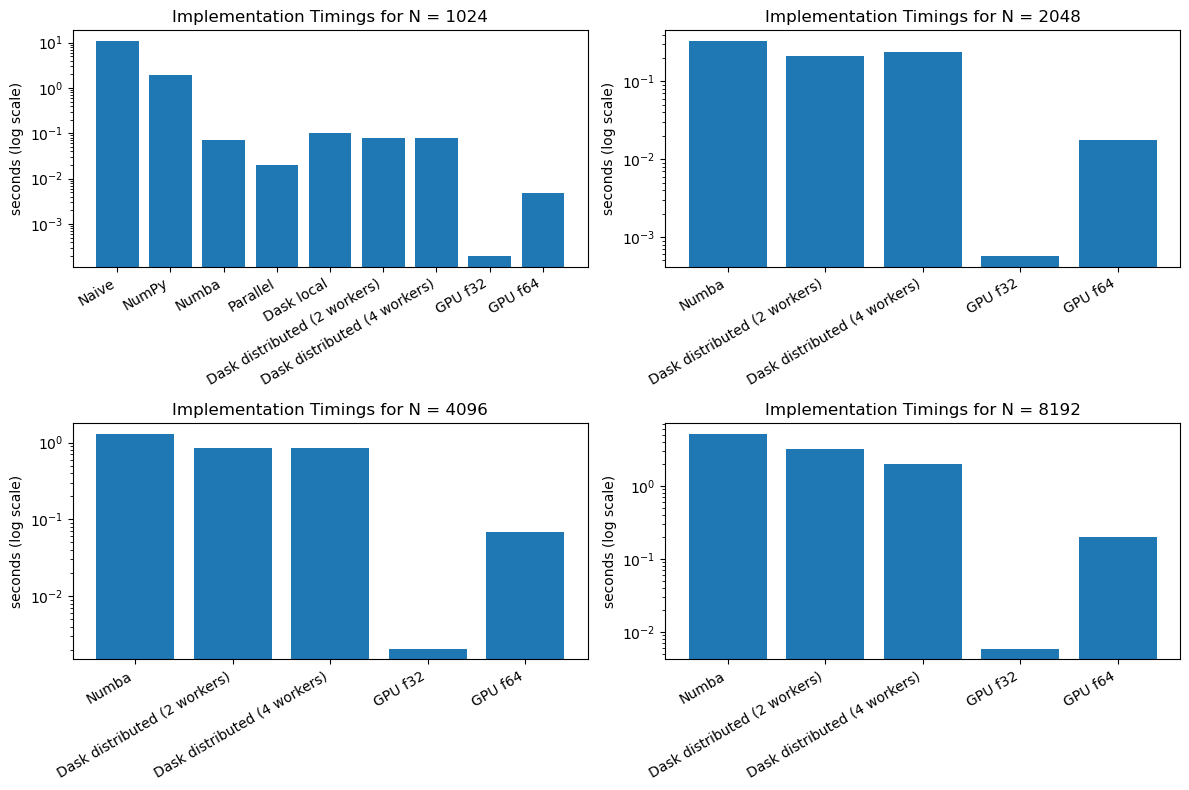

In [8]:
import warnings

N = [1024, 2048, 4096, 8192]
max_iter = 100
x_dim = (-2.5, 1.0)
y_dim = (-1.5, 1.5)
n_runs = 5

# Timings from MP2
implementation_times = {
    1024: {
        "Naive": 10.80,
        "NumPy": 1.94,
        "Numba": 0.07,
        "Parallel": 0.02,
        "Dask local": 0.10,
        "Dask distributed (2 workers)" : 0.08,
        "Dask distributed (4 workers)" : 0.08
    },
    2048: {
        "Numba": 0.33,
        "Dask distributed (2 workers)" : 0.21,
        "Dask distributed (4 workers)" : 0.24
    },
    4096: {
        "Numba": 1.31,
        "Dask distributed (2 workers)" : 0.84,
        "Dask distributed (4 workers)" : 0.86
    },
    8192: {
        "Numba": 5.23,
        "Dask distributed (2 workers)" : 3.25,
        "Dask distributed (4 workers)" : 2.00
    }
}

fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, n in enumerate(N):

    # GPU float32 benchmark
    times_f32 = []
    times_f64 = []
    for _ in range(n_runs):
        time_gpu_f32, _ = gpu.mandelbrot_gpu_f32(N=n, max_iter=max_iter, x_dim=x_dim, y_dim=y_dim) # GPU float32 timing
        time_gpu_f64, _ = gpu.mandelbrot_gpu_f64(N=n, max_iter=max_iter, x_dim=x_dim, y_dim=y_dim) # GPU float64 timing
        times_f32.append(time_gpu_f32)
        times_f64.append(time_gpu_f64)
    med_gpu_f32 = statistics.median(times_f32)
    med_gpu_f64 = statistics.median(times_f64)

    results = {}

    if n in implementation_times:
        results.update(implementation_times[n])

    results["GPU f32"] = med_gpu_f32
    results["GPU f64"] = med_gpu_f64

    names, times = zip(*results.items())

    ax = axes[i]
    ax.bar(names, times, log=True)
    ax.set_ylabel("seconds (log scale)")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_title(f'Implementation Timings for N = {n}')

plt.tight_layout()
plt.savefig(f"../figures/benchmark_mp3_N{n}.png", dpi=150)
plt.show()

## Lecture 10 - Additional test of CPU vs GPU consistency
These tests are included in the pytests for Lecture 10 - Milestone 1